# Deep Learning sur TF-IDF — MLP (Multi-Layer Perceptron)

Ce notebook entraîne un MLP PyTorch sur les features TF-IDF des avis Yelp.

**Architecture** : Input(10000) → Dense(256) → ReLU → Dropout(0.3) → Dense(128) → ReLU → Dropout(0.3) → Output

**Deux tâches de classification** :
1. **Polarité** (3 classes) : négatif (1-2★), neutre (3★), positif (4-5★)
2. **Score** (5 classes) : prédiction directe des étoiles (1-5)

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_parquet
from src.visualization import setup_plot_style, save_figure

import warnings
warnings.filterwarnings('ignore')

setup_plot_style()

## 1. Configuration

In [2]:
RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
MAX_FEATURES = 10_000
BATCH_SIZE = 256
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 5  # early stopping

MODELS_DIR = '../../models'
FIGURES_DIR = '../../outputs/figures'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Sélection du device (MPS pour Apple Silicon, CUDA pour GPU NVIDIA, sinon CPU)
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Device : {device}")

Device : mps


## 2. Chargement et Préparation des données

In [3]:
df = load_parquet('reviews_clean.parquet', base_path='../../data/cleaned', columns=['text', 'stars'])
df = df.dropna(subset=['text', 'stars'])

# Créer la colonne polarité
df['polarity'] = df['stars'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))

# Échantillonnage stratifié (même taille que le notebook ML classique)
df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

print(f"Taille du dataset : {df.shape[0]}")
print(f"\nDistribution Score (1-5) :\n{df['stars'].value_counts().sort_index()}")
print(f"\nDistribution Polarité :\n{df['polarity'].value_counts().sort_index()}")

Loaded 999,985 rows from reviews_clean.parquet


Taille du dataset : 10000

Distribution Score (1-5) :
stars
1    1558
2     746
3     995
4    2057
5    4644
Name: count, dtype: int64

Distribution Polarité :
polarity
0    2304
1     995
2    6701
Name: count, dtype: int64


## 3. Vectorisation TF-IDF

Mêmes paramètres que le notebook ML classique pour assurer la comparabilité.

In [4]:
X = df['text']
y_polarity = df['polarity'].values
y_score = (df['stars'].values - 1).astype(int)  # 0-indexed (0 à 4)

# Split 80/10/10 (train/val/test) — stratifié sur la polarité
X_train, X_temp, y_pol_train, y_pol_temp, y_sc_train, y_sc_temp = train_test_split(
    X, y_polarity, y_score, test_size=0.20, random_state=RANDOM_STATE, stratify=y_polarity
)
X_val, X_test, y_pol_val, y_pol_test, y_sc_val, y_sc_test = train_test_split(
    X_temp, y_pol_temp, y_sc_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_pol_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# TF-IDF : fit sur train uniquement pour éviter le data leakage
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES, min_df=5, max_df=0.7, ngram_range=(1, 2)
)
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_val_tfidf = vectorizer.transform(X_val).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()

print(f"Dimension TF-IDF : {X_train_tfidf.shape[1]} features")

Train: 8000 | Val: 1000 | Test: 1000


Dimension TF-IDF : 10000 features


## 4. Préparation des DataLoaders PyTorch

In [5]:
def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=BATCH_SIZE):
    """Convertit les arrays numpy en DataLoaders PyTorch."""
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )
    val_ds = TensorDataset(
        torch.tensor(X_v, dtype=torch.float32),
        torch.tensor(y_v, dtype=torch.long)
    )
    test_ds = TensorDataset(
        torch.tensor(X_te, dtype=torch.float32),
        torch.tensor(y_te, dtype=torch.long)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)
    return train_loader, val_loader, test_loader

## 5. Architecture du MLP

In [6]:
class MLP(nn.Module):
    """Multi-Layer Perceptron pour classification de texte."""
    
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

# Vérification de l'architecture
model_test = MLP(MAX_FEATURES, 3)
print(model_test)
n_params = sum(p.numel() for p in model_test.parameters())
print(f"\nNombre total de paramètres : {n_params:,}")
del model_test

MLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=3, bias=True)
  )
)

Nombre total de paramètres : 2,593,539


## 6. Fonctions d'entraînement et d'évaluation

In [7]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, patience=PATIENCE):
    """Entraîne le modèle avec early stopping sur la val loss."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        # --- Entraînement ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            train_correct += (outputs.argmax(1) == y_batch).sum().item()
            train_total += X_batch.size(0)
        
        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += X_batch.size(0)
        
        # Métriques de l'epoch
        t_loss = train_loss / train_total
        v_loss = val_loss / val_total
        t_acc = train_correct / train_total
        v_acc = val_correct / val_total
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        
        # Early stopping
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0 or patience_counter >= patience:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
                  f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")
        
        if patience_counter >= patience:
            print(f"Early stopping à l'epoch {epoch+1}")
            break
    
    # Restaurer les meilleurs poids
    model.load_state_dict(best_state)
    return model, history

In [8]:
def evaluate_model(model, test_loader):
    """Évalue le modèle sur le test set et retourne les prédictions."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


def plot_training_curves(history, title):
    """Affiche les courbes de loss et accuracy pendant l'entraînement."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train')
    ax2.plot(history['val_acc'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    return fig


def plot_confusion(y_true, y_pred, labels, title):
    """Affiche la matrice de confusion."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Matrice de confusion — {title}')
    plt.ylabel('Vrai')
    plt.xlabel('Prédit')
    plt.tight_layout()
    plt.show()

---
## 7. Tâche 1 : Prédiction de la Polarité (3 classes)

In [9]:
print("=" * 60)
print("TÂCHE 1 : POLARITÉ (négatif / neutre / positif)")
print("=" * 60)

train_loader_pol, val_loader_pol, test_loader_pol = make_loaders(
    X_train_tfidf, y_pol_train,
    X_val_tfidf, y_pol_val,
    X_test_tfidf, y_pol_test
)

model_pol = MLP(input_dim=X_train_tfidf.shape[1], num_classes=3)
model_pol, history_pol = train_model(model_pol, train_loader_pol, val_loader_pol)

TÂCHE 1 : POLARITÉ (négatif / neutre / positif)


Epoch   5/50 | Train Loss: 0.1147 Acc: 0.9706 | Val Loss: 0.4402 Acc: 0.8520


Epoch   8/50 | Train Loss: 0.0113 Acc: 0.9988 | Val Loss: 0.6519 Acc: 0.8470
Early stopping à l'epoch 8


Figure saved to: ../../outputs/figures/mlp_tfidf_polarite_curves.png


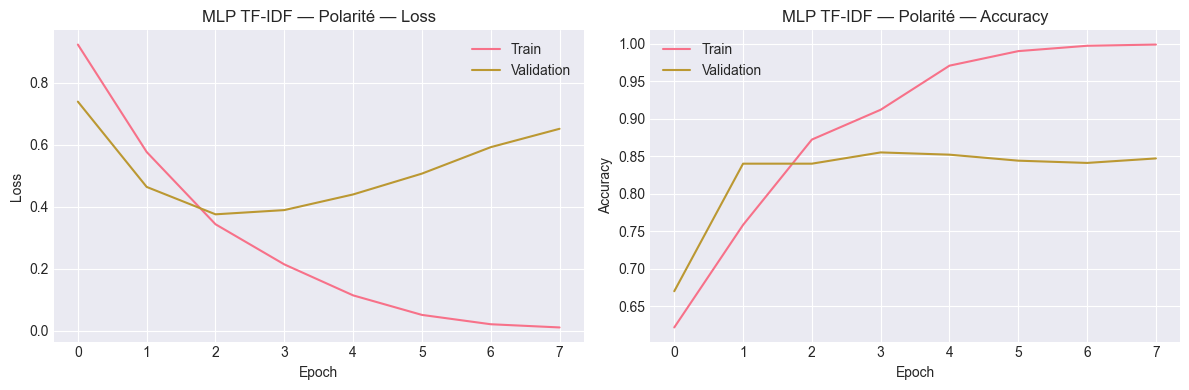

In [10]:
fig = plot_training_curves(history_pol, 'MLP TF-IDF — Polarité')
save_figure('mlp_tfidf_polarite_curves.png', output_dir='../../outputs/figures')


=== Résultats Polarité (Test Set) ===
Accuracy  : 0.8500
F1 Macro  : 0.5828
Precision : 0.8743
Recall    : 0.6215

Rapport de classification :
              precision    recall  f1-score   support

     Négatif       0.72      0.90      0.80       231
      Neutre       1.00      0.01      0.02        99
     Positif       0.90      0.96      0.93       670

    accuracy                           0.85      1000
   macro avg       0.87      0.62      0.58      1000
weighted avg       0.87      0.85      0.81      1000



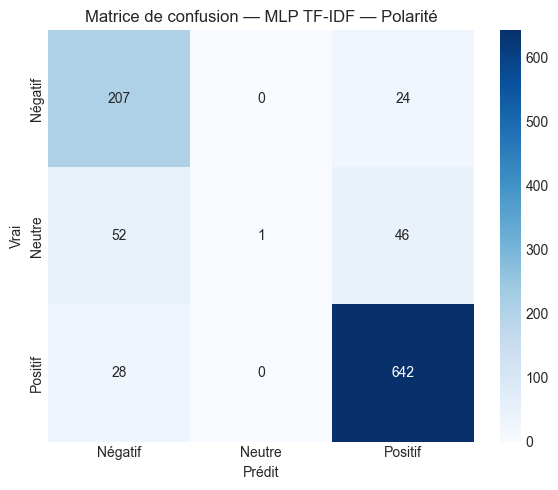

In [11]:
preds_pol, labels_pol = evaluate_model(model_pol, test_loader_pol)

pol_labels = ['Négatif', 'Neutre', 'Positif']
print("\n=== Résultats Polarité (Test Set) ===")
print(f"Accuracy  : {accuracy_score(labels_pol, preds_pol):.4f}")
print(f"F1 Macro  : {f1_score(labels_pol, preds_pol, average='macro'):.4f}")
print(f"Precision : {precision_score(labels_pol, preds_pol, average='macro'):.4f}")
print(f"Recall    : {recall_score(labels_pol, preds_pol, average='macro'):.4f}")
print("\nRapport de classification :")
print(classification_report(labels_pol, preds_pol, target_names=pol_labels))

plot_confusion(labels_pol, preds_pol, pol_labels, 'MLP TF-IDF — Polarité')

---
## 8. Tâche 2 : Prédiction du Score (1-5 étoiles)

In [12]:
print("=" * 60)
print("TÂCHE 2 : SCORE (1 à 5 étoiles)")
print("=" * 60)

train_loader_sc, val_loader_sc, test_loader_sc = make_loaders(
    X_train_tfidf, y_sc_train,
    X_val_tfidf, y_sc_val,
    X_test_tfidf, y_sc_test
)

model_score = MLP(input_dim=X_train_tfidf.shape[1], num_classes=5)
model_score, history_score = train_model(model_score, train_loader_sc, val_loader_sc)

TÂCHE 2 : SCORE (1 à 5 étoiles)


Epoch   5/50 | Train Loss: 0.4269 Acc: 0.8460 | Val Loss: 0.8793 Acc: 0.6420


Epoch   8/50 | Train Loss: 0.1219 Acc: 0.9761 | Val Loss: 1.3325 Acc: 0.6210
Early stopping à l'epoch 8


Figure saved to: ../../outputs/figures/mlp_tfidf_score_curves.png


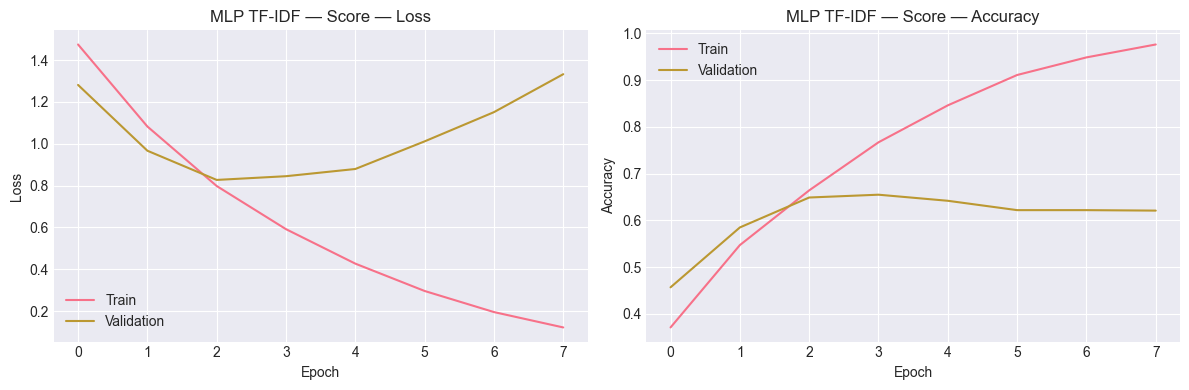

In [13]:
fig = plot_training_curves(history_score, 'MLP TF-IDF — Score')
save_figure('mlp_tfidf_score_curves.png', output_dir='../../outputs/figures')


=== Résultats Score (Test Set) ===
Accuracy  : 0.6650
F1 Macro  : 0.4726
Precision : 0.4919
Recall    : 0.4954

Rapport de classification :
              precision    recall  f1-score   support

          1★       0.61      0.89      0.72       155
          2★       0.00      0.00      0.00        76
          3★       0.58      0.25      0.35        99
          4★       0.53      0.43      0.47       220
          5★       0.74      0.91      0.81       450

    accuracy                           0.67      1000
   macro avg       0.49      0.50      0.47      1000
weighted avg       0.60      0.67      0.62      1000



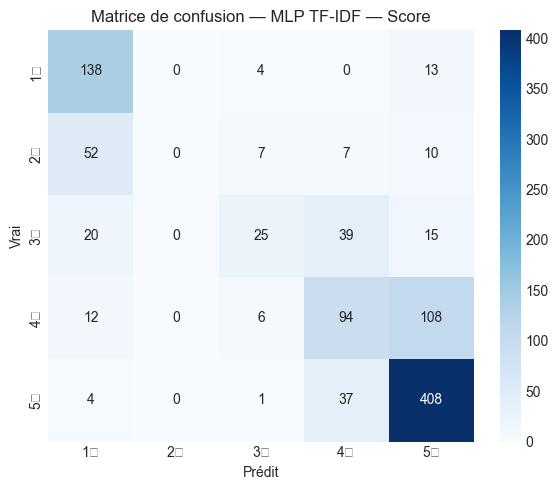

In [14]:
preds_sc, labels_sc = evaluate_model(model_score, test_loader_sc)

score_labels = ['1★', '2★', '3★', '4★', '5★']
print("\n=== Résultats Score (Test Set) ===")
print(f"Accuracy  : {accuracy_score(labels_sc, preds_sc):.4f}")
print(f"F1 Macro  : {f1_score(labels_sc, preds_sc, average='macro'):.4f}")
print(f"Precision : {precision_score(labels_sc, preds_sc, average='macro'):.4f}")
print(f"Recall    : {recall_score(labels_sc, preds_sc, average='macro'):.4f}")
print("\nRapport de classification :")
print(classification_report(labels_sc, preds_sc, target_names=score_labels))

plot_confusion(labels_sc, preds_sc, score_labels, 'MLP TF-IDF — Score')

## 9. Comparaison avec le ML Classique

In [15]:
comparison = pd.DataFrame({
    'Modèle': ['MLP (Polarité)', 'MLP (Score)'],
    'Accuracy': [
        accuracy_score(labels_pol, preds_pol),
        accuracy_score(labels_sc, preds_sc)
    ],
    'F1 Macro': [
        f1_score(labels_pol, preds_pol, average='macro'),
        f1_score(labels_sc, preds_sc, average='macro')
    ],
    'Precision Macro': [
        precision_score(labels_pol, preds_pol, average='macro'),
        precision_score(labels_sc, preds_sc, average='macro')
    ],
    'Recall Macro': [
        recall_score(labels_pol, preds_pol, average='macro'),
        recall_score(labels_sc, preds_sc, average='macro')
    ]
}).set_index('Modèle')

print("=== RÉSUMÉ DES PERFORMANCES MLP TF-IDF ===")
display(comparison)

=== RÉSUMÉ DES PERFORMANCES MLP TF-IDF ===


,Accuracy,F1 Macro,Precision Macro,Recall Macro
Modèle,,,,
MLP (Polarité),0.850,0.582772,0.874313,0.621471
MLP (Score),0.665,0.472565,0.491910,0.495357


## 10. Sauvegarde des modèles

In [16]:
# Sauvegarder les modèles PyTorch
torch.save(model_pol.state_dict(), os.path.join(MODELS_DIR, 'mlp_tfidf_polarity.pt'))
torch.save(model_score.state_dict(), os.path.join(MODELS_DIR, 'mlp_tfidf_score.pt'))

print(f"Modèle Polarité sauvegardé : {MODELS_DIR}/mlp_tfidf_polarity.pt")
print(f"Modèle Score sauvegardé    : {MODELS_DIR}/mlp_tfidf_score.pt")

Modèle Polarité sauvegardé : ../../models/mlp_tfidf_polarity.pt
Modèle Score sauvegardé    : ../../models/mlp_tfidf_score.pt


## Conclusion

Le MLP PyTorch sur features TF-IDF offre une première architecture deep learning pour la classification de sentiment.

**Points clés** :
- L'early stopping empêche le sur-apprentissage (arrêt automatique quand la val loss stagne)
- Les courbes train/val permettent de diagnostiquer le comportement du modèle
- Les résultats sont comparables aux modèles ML classiques (notebook `01-ml-tfidf`)

**Prochaines étapes** :
- Tester d'autres architectures deep (CNN sur n-grams, fine-tuning DistilBERT)
- Comparer toutes les approches dans le notebook de pipeline optimale